In [11]:
# Importing Libs
import pandas as pd
import numpy as np 
import fastf1
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
#caching F1 data
fastf1.Cache.enable_cache('../f1_Cache')
print("Cache Enabled Successfully")

Cache Enabled Successfully


In [25]:
#load sessions
session = fastf1.get_session(2025,'Bahrain','R')
session.load()

laps = session.laps
print(f"Total laps loaded: {len(laps)}")
print(f"\nColumns available:\n{list(laps.columns)}")

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

Total laps loaded: 1128

Columns available:
['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']


#### Things i have noticed so far after loaded a Bahrain Race session
- As we have kept some cache, it checked if same data was there in the cache and if not it loaded
- Understod the columns and their reasoning behind it.


In [32]:
#Understanding data
print(laps.dtypes)
print('\n')
print(laps.head(5))

Time                  timedelta64[ns]
Driver                         object
DriverNumber                   object
LapTime               timedelta64[ns]
LapNumber                     float64
Stint                         float64
PitOutTime            timedelta64[ns]
PitInTime             timedelta64[ns]
Sector1Time           timedelta64[ns]
Sector2Time           timedelta64[ns]
Sector3Time           timedelta64[ns]
Sector1SessionTime    timedelta64[ns]
Sector2SessionTime    timedelta64[ns]
Sector3SessionTime    timedelta64[ns]
SpeedI1                       float64
SpeedI2                       float64
SpeedFL                       float64
SpeedST                       float64
IsPersonalBest                   bool
Compound                       object
TyreLife                      float64
FreshTyre                        bool
Team                           object
LapStartTime          timedelta64[ns]
LapStartDate           datetime64[ns]
TrackStatus                    object
Position    

In [42]:
type(laps)
df = pd.DataFrame(laps)
df

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:57:13.827000,PIA,81,0 days 00:01:38.693000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:42.130000,...,False,McLaren,0 days 00:55:34.907000,2025-04-13 15:03:49.174,1,1.0,False,,False,False
1,0 days 00:58:51.319000,PIA,81,0 days 00:01:37.492000,2.0,1.0,NaT,NaT,0 days 00:00:31.139000,0 days 00:00:42.343000,...,False,McLaren,0 days 00:57:13.827000,2025-04-13 15:05:28.094,1,1.0,False,,False,True
2,0 days 01:00:29.402000,PIA,81,0 days 00:01:38.083000,3.0,1.0,NaT,NaT,0 days 00:00:31.306000,0 days 00:00:42.727000,...,False,McLaren,0 days 00:58:51.319000,2025-04-13 15:07:05.586,1,1.0,False,,False,True
3,0 days 01:02:07.535000,PIA,81,0 days 00:01:38.133000,4.0,1.0,NaT,NaT,0 days 00:00:31.326000,0 days 00:00:42.796000,...,False,McLaren,0 days 01:00:29.402000,2025-04-13 15:08:43.669,1,1.0,False,,False,True
4,0 days 01:03:45.578000,PIA,81,0 days 00:01:38.043000,5.0,1.0,NaT,NaT,0 days 00:00:31.305000,0 days 00:00:42.690000,...,False,McLaren,0 days 01:02:07.535000,2025-04-13 15:10:21.802,1,1.0,False,,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1123,0 days 02:25:33.298000,HUL,27,0 days 00:01:38.260000,53.0,3.0,NaT,NaT,0 days 00:00:31.255000,0 days 00:00:42.821000,...,True,Kick Sauber,0 days 02:23:55.038000,2025-04-13 16:32:09.305,1,15.0,False,,False,True
1124,0 days 02:27:11.796000,HUL,27,0 days 00:01:38.498000,54.0,3.0,NaT,NaT,0 days 00:00:31.388000,0 days 00:00:42.992000,...,True,Kick Sauber,0 days 02:25:33.298000,2025-04-13 16:33:47.565,1,15.0,False,,False,True
1125,0 days 02:28:50.220000,HUL,27,0 days 00:01:38.424000,55.0,3.0,NaT,NaT,0 days 00:00:31.415000,0 days 00:00:42.892000,...,True,Kick Sauber,0 days 02:27:11.796000,2025-04-13 16:35:26.063,1,15.0,False,,False,True
1126,0 days 02:30:29.218000,HUL,27,0 days 00:01:38.998000,56.0,3.0,NaT,NaT,0 days 00:00:31.369000,0 days 00:00:43.236000,...,True,Kick Sauber,0 days 02:28:50.220000,2025-04-13 16:37:04.487,1,15.0,False,,False,True


In [43]:
print('Null counts per col:')
print(df.isnull().sum())

Null counts per col:
Time                     0
Driver                   0
DriverNumber             0
LapTime                 13
LapNumber                0
Stint                    0
PitOutTime            1086
PitInTime             1085
Sector1Time             40
Sector2Time             20
Sector3Time             20
Sector1SessionTime      44
Sector2SessionTime      20
Sector3SessionTime      20
SpeedI1                  0
SpeedI2                  0
SpeedFL                 43
SpeedST                  0
IsPersonalBest           0
Compound                 0
TyreLife                 0
FreshTyre                0
Team                     0
LapStartTime             0
LapStartDate             0
TrackStatus              0
Position                 0
Deleted                  0
DeletedReason            0
FastF1Generated          0
IsAccurate               0
dtype: int64


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype          
---  ------              --------------  -----          
 0   Time                1128 non-null   timedelta64[ns]
 1   Driver              1128 non-null   object         
 2   DriverNumber        1128 non-null   object         
 3   LapTime             1115 non-null   timedelta64[ns]
 4   LapNumber           1128 non-null   float64        
 5   Stint               1128 non-null   float64        
 6   PitOutTime          42 non-null     timedelta64[ns]
 7   PitInTime           43 non-null     timedelta64[ns]
 8   Sector1Time         1088 non-null   timedelta64[ns]
 9   Sector2Time         1108 non-null   timedelta64[ns]
 10  Sector3Time         1108 non-null   timedelta64[ns]
 11  Sector1SessionTime  1084 non-null   timedelta64[ns]
 12  Sector2SessionTime  1108 non-null   timedelta64[ns]
 13  Sector3SessionTime  1108 non-null

#### Data exploration 
- Looked through data and data types
- Noticed few null cols mostly for pit ins & outs

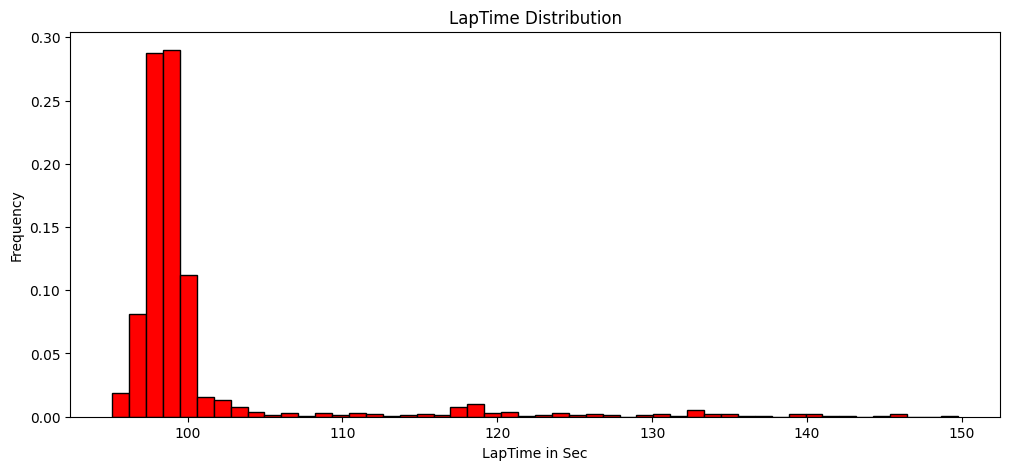

In [52]:
# Viz1 - LapTime Distribution
laps['laptimeInSeconds'] = laps['LapTime'].dt.total_seconds()
laps['laptimeInSeconds']

plt.figure(figsize=(12,5))
plt.hist(laps['laptimeInSeconds'].dropna(),bins = 50,color='red',edgecolor='black')
plt.title('LapTime Distribution')
plt.xlabel('LapTime in Sec')
plt.ylabel('Frequency')
plt.savefig('../outputs/plots/bahrain_hist_laptimesecs.png')
plt.show()


C:\Users\Buncy\AppData\Local\Temp\ipykernel_32568\2219785502.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clean_laps,x='Compound',y='laptimeInSeconds',palette='Set2')


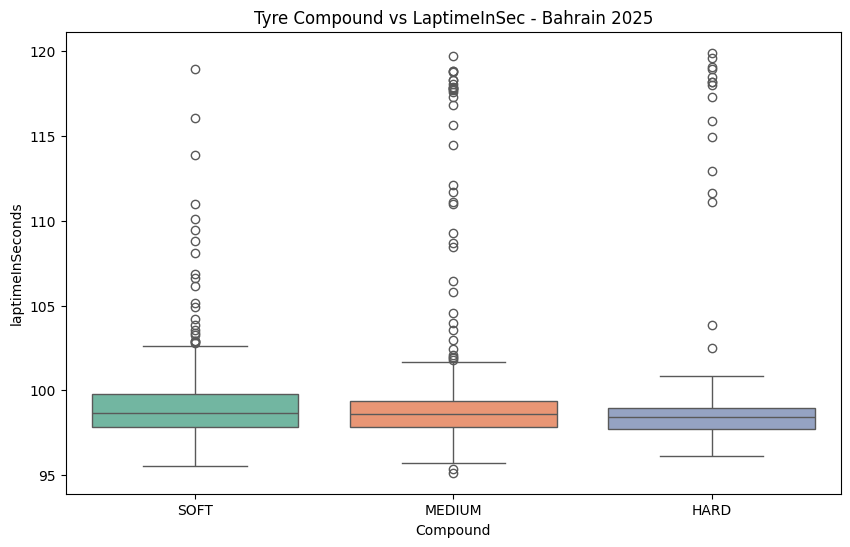

In [57]:
# Viz2 - Tyre Compound vs Laptime
clean_laps = laps.dropna(subset = ['laptimeInSeconds','Compound'])
clean_laps = clean_laps[clean_laps['laptimeInSeconds'] < 120]

plt.figure(figsize=(10,6))
sns.boxplot(data=clean_laps,x='Compound',y='laptimeInSeconds',palette='Set2')
plt.title('Tyre Compound vs LaptimeInSec - Bahrain 2025')
plt.savefig('../outputs/plots/tyrecompund_vs_Laptime_Bahrain2025')
plt.show()

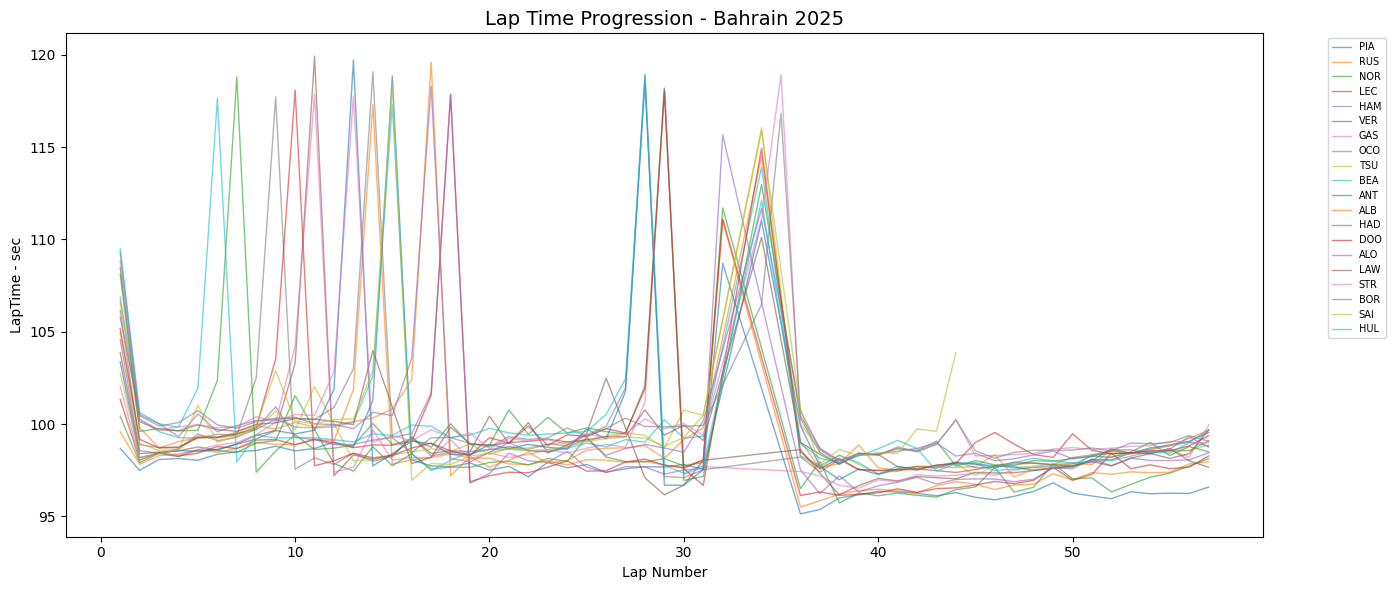

In [60]:
# Viz 3 - Laps vs Driver
clean_laps_2 = laps.dropna(subset=['laptimeInSeconds'])
clean_laps_2 = clean_laps_2[clean_laps_2['laptimeInSeconds'].between(80,120)]

plt.figure(figsize=(14,6))

for driver in clean_laps_2['Driver'].unique():
    driver_laps = clean_laps_2[clean_laps_2['Driver']==driver]
    plt.plot(driver_laps['LapNumber'],driver_laps['laptimeInSeconds'],alpha=0.6,linewidth=1,label=driver)

plt.title('Lap Time Progression - Bahrain 2025',fontsize=14)
plt.xlabel('Lap Number')
plt.ylabel('LapTime - sec')
plt.legend(bbox_to_anchor=(1.05,1),loc='upper left',fontsize=7)
plt.tight_layout()
plt.savefig('../outputs/plots/lap_progression.png')
plt.show()

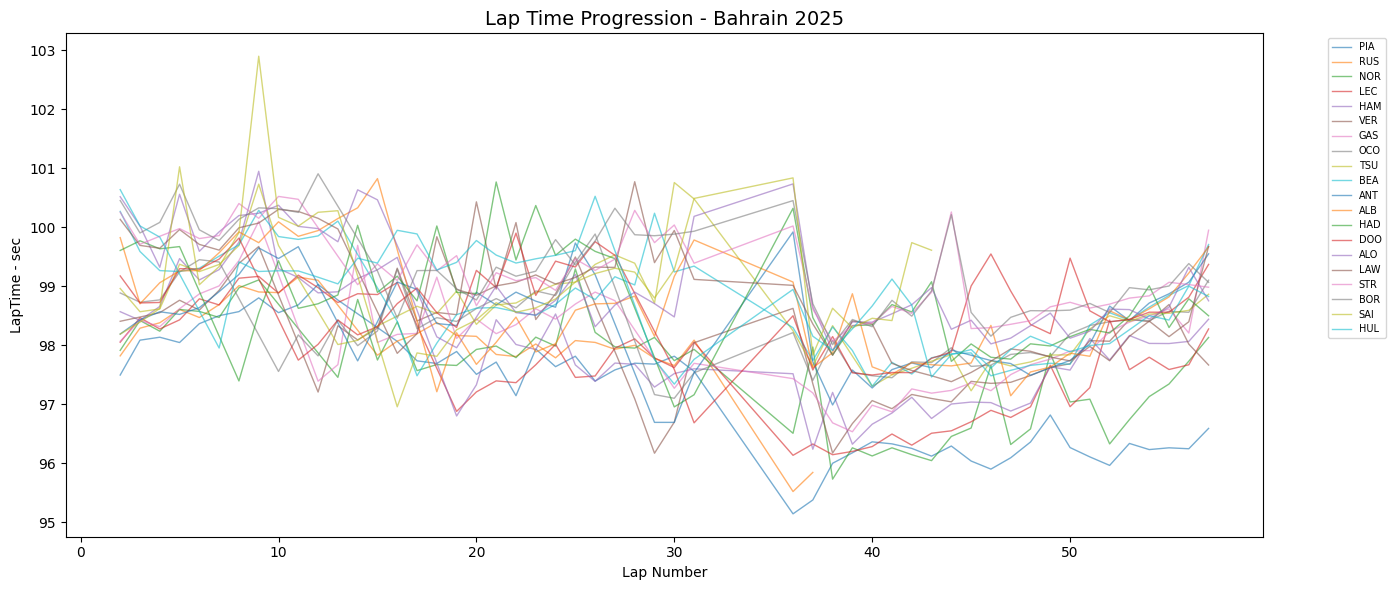

In [61]:
#viz 4 - 
clean_laps_2 = laps.dropna(subset=['laptimeInSeconds'])
clean_laps_2 = clean_laps_2[clean_laps_2['IsAccurate']==True]
clean_laps_2 = clean_laps_2[clean_laps_2['laptimeInSeconds'].between(80,120)]

plt.figure(figsize=(14,6))

for driver in clean_laps_2['Driver'].unique():
    driver_laps = clean_laps_2[clean_laps_2['Driver']==driver]
    plt.plot(driver_laps['LapNumber'],driver_laps['laptimeInSeconds'],alpha=0.6,linewidth=1,label=driver)

plt.title('Lap Time Progression - Bahrain 2025',fontsize=14)
plt.xlabel('Lap Number')
plt.ylabel('LapTime - sec')
plt.legend(bbox_to_anchor=(1.05,1),loc='upper left',fontsize=7)
plt.tight_layout()
plt.savefig('../outputs/plots/lap_progression_wo_unreliable_events.png')
plt.show()

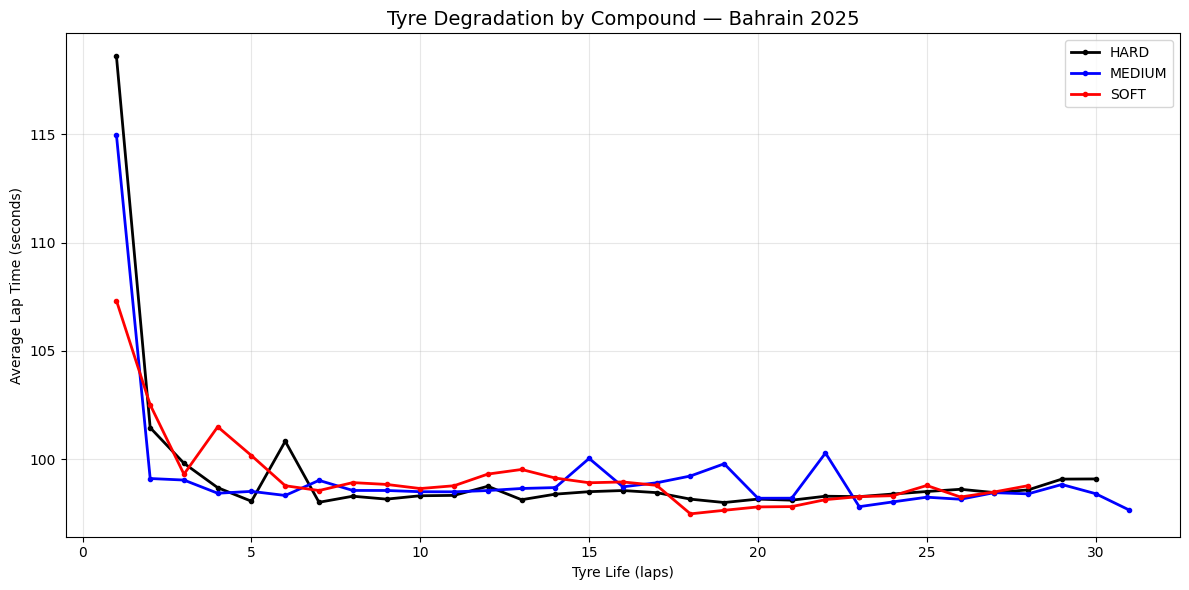

In [64]:
# viz5
clean_laps_3 = laps.dropna(subset=['laptimeInSeconds', 'Compound', 'TyreLife'])
clean_laps_3 = clean_laps[clean_laps['laptimeInSeconds'].between(80, 120)]

degradation = clean_laps_3.groupby(['Compound', 'TyreLife'])['laptimeInSeconds'].mean().reset_index()

plt.figure(figsize=(12, 6))
compounds = degradation['Compound'].unique()
colors = {'SOFT': 'red', 'MEDIUM': 'blue', 'HARD': 'black', 
          'INTERMEDIATE': 'green', 'WET': 'blue'}

for compound in compounds:
    data = degradation[degradation['Compound'] == compound]
    color = colors.get(compound, 'grey')
    plt.plot(data['TyreLife'], data['laptimeInSeconds'], 
             marker='o', markersize=3, linewidth=2,
             label=compound, color=color)

plt.title('Tyre Degradation by Compound — Bahrain 2025', fontsize=14)
plt.xlabel('Tyre Life (laps)')
plt.ylabel('Average Lap Time (seconds)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/plots/tyre_degradation.png')
plt.show()

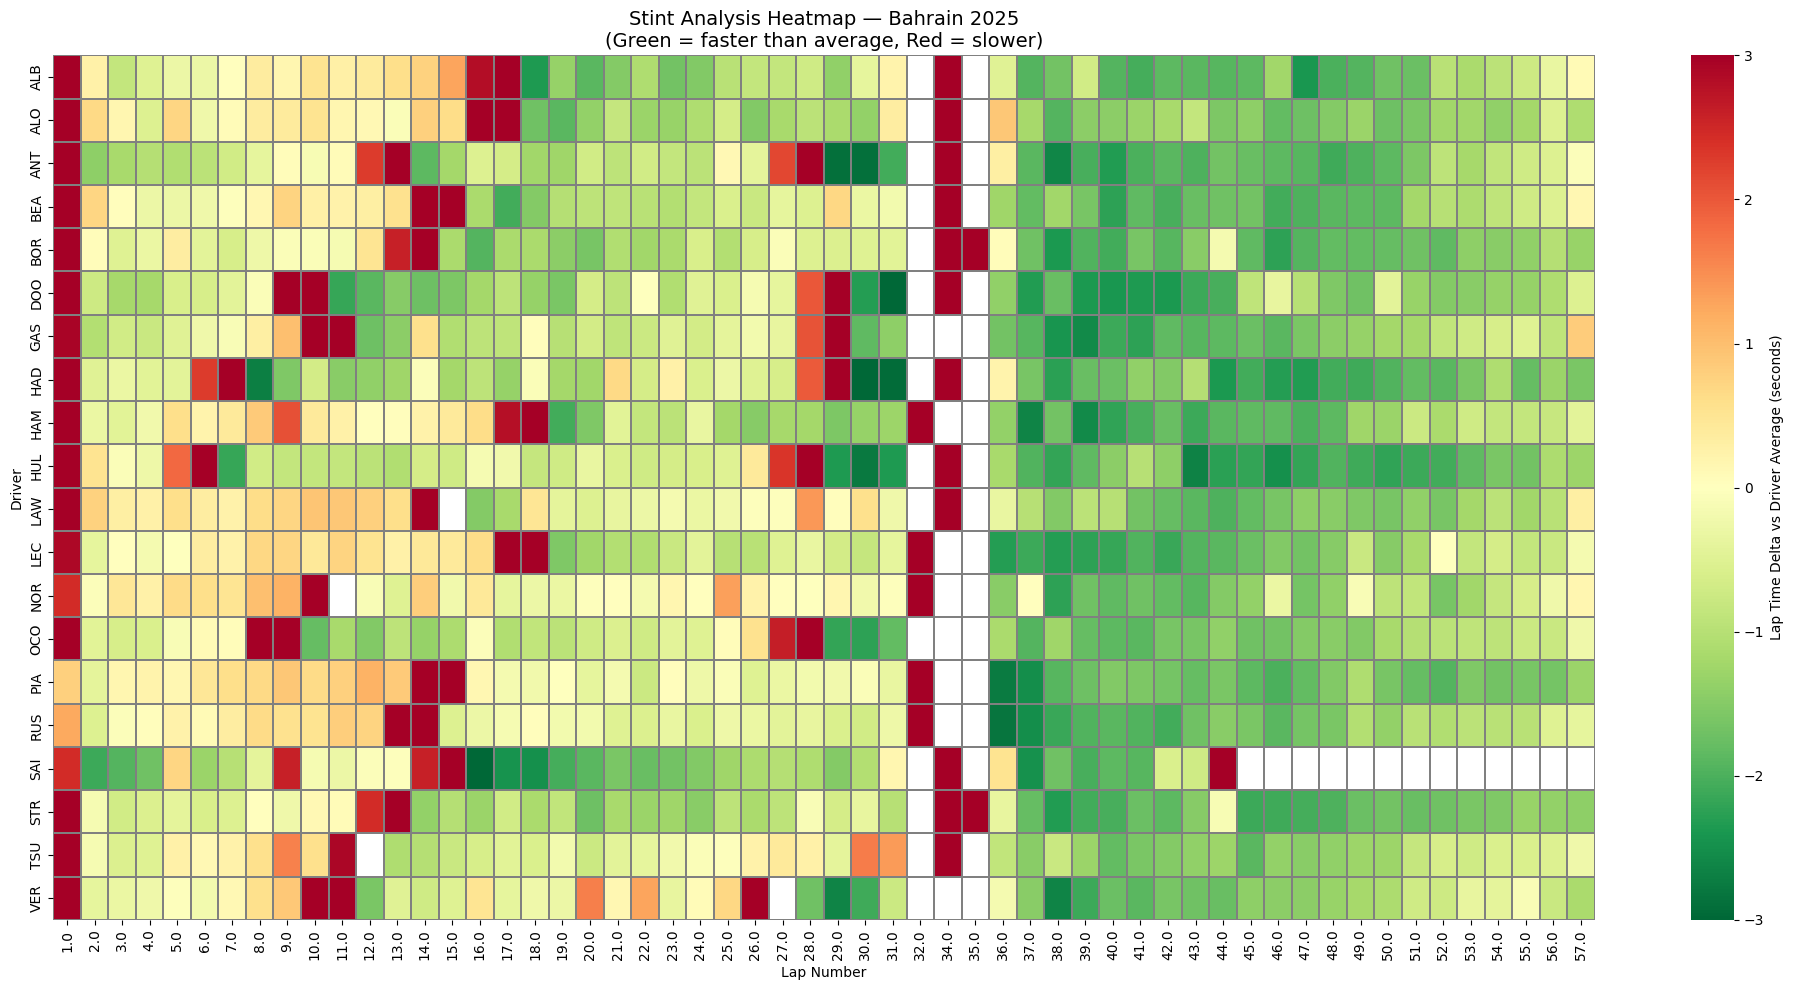

In [66]:
# Viz 6 
clean_laps_4 = laps.dropna(subset=['laptimeInSeconds'])
clean_laps_4 = clean_laps[clean_laps['laptimeInSeconds'].between(80, 120)].copy()

# compute each driver's personal average
driver_avg = clean_laps_4.groupby('Driver')['laptimeInSeconds'].transform('mean')
clean_laps_4['LapTimeDelta'] = clean_laps_4['laptimeInSeconds'] - driver_avg

# pivot to heatmap format
pivot = clean_laps_4.pivot_table(
    index='Driver', 
    columns='LapNumber', 
    values='LapTimeDelta', 
    aggfunc='mean'
)

plt.figure(figsize=(20, 10))
sns.heatmap(
    pivot,
    cmap='RdYlGn_r',
    center=0,
    vmin=-3,
    vmax=3,
    linewidths=0.1,
    linecolor='grey',
    cbar_kws={'label': 'Lap Time Delta vs Driver Average (seconds)'}
)

plt.title('Stint Analysis Heatmap — Bahrain 2025\n(Green = faster than average, Red = slower)', fontsize=14)
plt.xlabel('Lap Number')
plt.ylabel('Driver')
plt.tight_layout()
plt.savefig('../outputs/plots/stint_heatmap.png')
plt.show()